<a href="https://colab.research.google.com/github/Abena-3565/Amharic-News-Text-classification_NLP_Project/blob/main/NLP_News_Classiffication.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Install kaggle API**

In [1]:
!pip install kaggle

**Upload the kaggel API**

In [ ]:
from google.colab import files
files.upload()

**Move API File to Kaggle folder**

In [ ]:
import os
os.makedirs('root/kaggle', exist_ok=True)
!mv kaggle.json root/kaggle
!chmod 600 root/kaggle/kaggle.json

mv: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access 'root/kaggle/kaggle.json': No such file or directory


**Download Dataset**

In [2]:
!kaggle datasets download -d mathurinache/amharicnewstextclassificationdataset

Dataset URL: https://www.kaggle.com/datasets/mathurinache/amharicnewstextclassificationdataset
License(s): CC-BY-NC-SA-4.0
100% 50.1M/50.1M [00:00<00:00, 106MB/s]



**Extract or Unzip dataset**

In [3]:
!unzip amharicnewstextclassificationdataset.zip

Archive:  amharicnewstextclassificationdataset.zip
  inflating: Amharic News Dataset.csv  


**Import Library**

In [4]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

import matplotlib.pyplot as plt
import re

from tensorflow.keras.layers import Bidirectional
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import confusion_matrix
import seaborn as sns


**Load dataset**

In [5]:
data = pd.read_csv("/content/Amharic News Dataset.csv")

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51483 entries, 0 to 51482
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   headline  51470 non-null  object
 1   category  51482 non-null  object
 2   date      51483 non-null  object
 3   views     51483 non-null  object
 4   article   51483 non-null  object
 5   link      51483 non-null  object
dtypes: object(6)
memory usage: 2.4+ MB


# **Explore Data Analysis**

In [6]:
# to view the first 5 rows data
data.head()

,headline,category,date,views,article,link
0,የኦሊምፒክ ማጣሪያ ተሳታፊዎች የሚለዩበት ቻምፒዮና እየተካሄደ ይገኛል,ስፖርት,"January 14, 2021",2,ብርሃን ፈይሳየኢትዮጵያ ቦክስ ፌዴሬሽን በየዓመቱ የሚያዘጋጀው የክለቦች ቻ...,https://www.press.et/Ama/?p=39481
1,አዲስ ዘመን ድሮ,መዝናኛ,"December 28, 2020",4,የአዲስ ዘመን ጋዜጣ ቀደምት ዘገባዎች በእጅጉ ተነባቢ ዛሬም ላገኛቸው በ...,https://www.press.et/Ama/?p=38334
2,የአረንጓዴ ጎርፍ በጎ አድራጎት አምባሳደሮች ተሰየሙ,ስፖርት,"January 6, 2021",6,ቦጋለ አበበየአዲስ አበባ ከተማ አስተዳደር ስፖርት ኮሚሽን ከኢትዮጵያ አረ...,https://www.press.et/Ama/?p=39010
3,የሊጉ በቢዝነስ ሞዴል መመራት አበረታች ጅምር መሆኑ ተገለጸ,ስፖርት,"January 6, 2021",5,ብርሃን ፈይሳአዲስ አበባ፡- የኢትዮጵያ ፕሪምየር ሊግ በሼር ካምፓኒ እንዲ...,https://www.press.et/Ama/?p=39011
4,የኦሊምፒክ ሥራ አስፈፃሚው እስከ ቶኪዮ ኦሊምፒክ ማግስት ይቀጥላል,ስፖርት,"January 6, 2021",12,ቦጋለ አበበ የኢትዮጵያ ኦሊምፒክ ኮሚቴ አርባ አምስተኛ መደበኛ ጠቅላላ ጉ...,https://www.press.et/Ama/?p=39012


In [7]:
#Unique value on each column
data.nunique()

,0
headline,50095
category,6
date,6189
views,4408
article,50285
link,50778


In [8]:
#The variation on target class
data["category"].value_counts()

,count
category,
ሀገር አቀፍ ዜና,20674
ስፖርት,10411
ፖለቲካ,9325
ዓለም አቀፍ ዜና,6543
ቢዝነስ,3894
መዝናኛ,635


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 4608 (\N{ETHIOPIC SYLLABLE HA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 4872 (\N{ETHIOPIC SYLLABLE GA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 4653 (\N{ETHIOPIC SYLLABLE RE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 4768 (\N{ETHIOPIC SYLLABLE GLOTTAL A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 4672 (\N{ETHIOPIC SYLLABLE QA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw

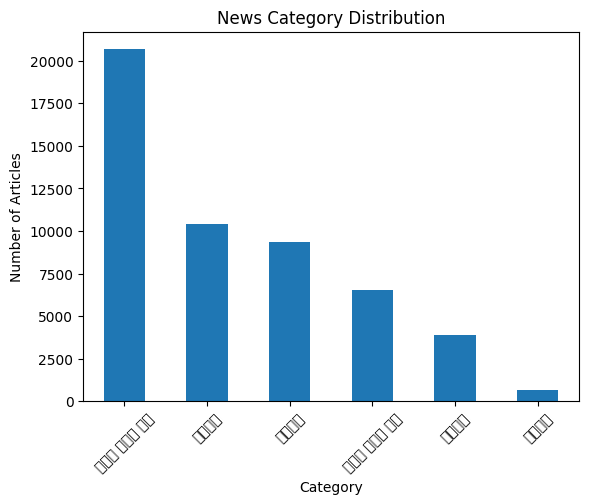

In [9]:
data['category'].value_counts().plot(kind='bar')

plt.title("News Category Distribution")
plt.xlabel("Category")
plt.ylabel("Number of Articles")
plt.xticks(rotation=45)


plt.show()

# **Data Cleaning**

In [10]:
#Keep only relevant column
data = data[['headline','article','category']]

In [11]:
data.dropna(inplace=True)

In [12]:
data.isnull().sum()

,0
headline,0
article,0
category,0


In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 51470 entries, 0 to 51482
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   headline  51470 non-null  object
 1   article   51470 non-null  object
 2   category  51470 non-null  object
 3   text      51470 non-null  object
dtypes: object(4)
memory usage: 2.0+ MB


In [13]:
# Combine headline and article
data["text"] = data['headline'] + " " + data['article']

In [15]:
data = data[['text','category']]

In [16]:
data.head()

,text,category
0,የኦሊምፒክ ማጣሪያ ተሳታፊዎች የሚለዩበት ቻምፒዮና እየተካሄደ ይገኛል ብር...,ስፖርት
1,አዲስ ዘመን ድሮ የአዲስ ዘመን ጋዜጣ ቀደምት ዘገባዎች በእጅጉ ተነባቢ ...,መዝናኛ
2,የአረንጓዴ ጎርፍ በጎ አድራጎት አምባሳደሮች ተሰየሙ ቦጋለ አበበየአዲስ አ...,ስፖርት
3,የሊጉ በቢዝነስ ሞዴል መመራት አበረታች ጅምር መሆኑ ተገለጸ ብርሃን ፈይሳ...,ስፖርት
4,የኦሊምፒክ ሥራ አስፈፃሚው እስከ ቶኪዮ ኦሊምፒክ ማግስት ይቀጥላል ቦጋለ ...,ስፖርት


# Data Preprocessing

Categorical Encode

In [17]:
encoder = LabelEncoder()
data['category_encoded'] = encoder.fit_transform(data['category'])

In [18]:
data.tail()

,text,category,category_encoded
51478,የ2011 በጀት ዓመት የውጭ ዲሎማሲያዊ ተግባራት ስኬታማ እንደነበሩ ተገለ...,ፖለቲካ,5
51479,አቶ አገኘሁ ተሻገር የሰላም ግንባታና የሕዝብ ደህንነት ኃላፊ ሆነው ተሾሙ...,ፖለቲካ,5
51480,የአማራ ክልል ምክር ቤት የ230 ዳኞችን ሹመት አጸደቀ የአማራ ክልል ምክ...,ፖለቲካ,5
51481,ሃምሌ 22 ለሚካሄደው የችግኝ ተከላ መርሀ-ግብር 54 ሚሊየን ብር ተመድቧ...,ሀገር አቀፍ ዜና,0
51482,ለህግ የበላይነት መከበር ሁሉም በጋራ መስራት እንዳለበት ተጠቆመ የፍትህ ...,ሀገር አቀፍ ዜና,0


To ensure Vocabular connsistency

In [19]:
def clean_amharic_text(text):

    text = text.lower()
    # remove numbers
    text = re.sub(r'[0-9]', '', text)
    # remove punctuation
    text = re.sub(r'[^\w\s]', '', text)
    # remove extra spaces
    text = re.sub(r'\s+', ' ', text)

    return text.strip()

Apply cleaning

In [20]:
data['text'] = data['text'].apply(clean_amharic_text)

Split data into train and test

In [22]:
X = data['text']
y = data['category_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

Tokenization

In [23]:
vocab_size = 30000

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

Convert text to sequence

In [24]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

Padding

In [25]:
max_length = 300
X_train_pad = pad_sequences(X_train_seq, maxlen=max_length)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length)

Build the LSTM model

In [26]:
model = Sequential()

model.add(Embedding(
    input_dim=vocab_size,
    output_dim=128,
    input_length=max_length
))

model.add(Bidirectional(LSTM(128, return_sequences=True)))
model.add(Dropout(0.5))
model.add(Bidirectional(LSTM(64)))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(6, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Compile the model

In [27]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Early stoping if the mode stop imporving

In [28]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

Train the model

In [ ]:
history = model.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop]
)

Epoch 1/10
580/580 ━━━━━━━━━━━━━━━━━━━━ 883s 2s/step - accuracy: 0.6686 - loss: 0.8793 - val_accuracy: 0.7562 - val_loss: 0.6371
Epoch 2/10
580/580 ━━━━━━━━━━━━━━━━━━━━ 946s 2s/step - accuracy: 0.8174 - loss: 0.5291 - val_accuracy: 0.7725 - val_loss: 0.6442
Epoch 3/10
580/580 ━━━━━━━━━━━━━━━━━━━━ 920s 2s/step - accuracy: 0.8838 - loss: 0.3596 - val_accuracy: 0.7953 - val_loss: 0.5817
Epoch 4/10
580/580 ━━━━━━━━━━━━━━━━━━━━ 920s 2s/step - accuracy: 0.9147 - loss: 0.2762 - val_accuracy: 0.7955 - val_loss: 0.6771
Epoch 5/10
580/580 ━━━━━━━━━━━━━━━━━━━━ 927s 2s/step - accuracy: 0.9285 - loss: 0.2314 - val_accuracy: 0.7863 - val_loss: 0.7107


Evaluate the model

In [ ]:
loss, accuracy = model.evaluate(X_test_pad, y_test)
print("Test Accuracy:", accuracy)

NameError: name 'model' is not defined

Confusion Matrix

In [ ]:
y_pred = model.predict(X_test_pad)
y_pred = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

Plot training result

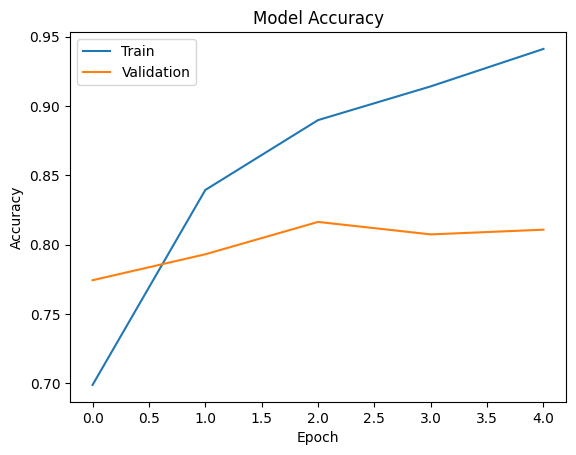

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(['Train','Validation'])

plt.show()

Predict New News

In [ ]:
sample = ["የኢትዮጵያ ብሔራዊ ቡድን በአፍሪካ ጨዋታ አሸነፈ"]

seq = tokenizer.texts_to_sequences(sample)
pad = pad_sequences(seq, maxlen=max_length)
pred = model.predict(pad)
category = encoder.inverse_transform([np.argmax(pred)])
print("Predicted Category:", category[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
Predicted Category: ስፖርት


In [30]:
# Configure git in colab
!git config --global user.email "abenezeralz65@gmail.com"
!git config --global user.name "https://github.com/Abena-3565"

In [32]:
# clone git repositer
!git clone https://github.com/Abena-3565/Amharic-News-Text-classification_NLP_Project.git

Cloning into 'Amharic-News-Text-classification_NLP_Project'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.


In [33]:
# Move into repo
%cd Amharic-News-Text-classification_NLP_Project

/content/Amharic-News-Text-classification_NLP_Project


In [37]:
# copy nootbook inot repo
!cp /NLP_News_Classiffication.ipynb /content/Amharic-News-Text-classification_NLP_Project/

cp: cannot stat '/NLP_News_Classiffication.ipynb': No such file or directory


In [40]:
!find /content -name "*.ipynb"